# Week 2 - Data Exploration & Pipeline Verification

**Literature:**
- Suzuki & Matsuo (2022) - understanding data heterogeneity before modelling
- Liu et al. (2023) LLaVA - model used in sanity check
- Radford et al. (2021) CLIP - evaluation metric


In [ ]:
# CELL 1 - Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [ ]:
# CELL 2 - Install packages

!pip install -q --upgrade accelerate
!pip install -q sentencepiece nltk

import nltk
nltk.download('punkt',   quiet=True)
nltk.download('wordnet', quiet=True)

import transformers
print(f'transformers : {transformers.__version__}')
print('Packages ready. No restart needed.')

transformers : 5.13.1
Packages ready. No restart needed.


In [ ]:
# CELL 3 - Set all paths

import os

BASE           = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR  = f'{BASE}/data/processed'
COCO_IMG_DIR   = f'{BASE}/data/coco/val2017'
COCO_INST_FILE = f'{BASE}/data/coco/annotations/instances_val2017.json'
RESULTS_DIR    = f'{BASE}/results'
MODELS_DIR     = f'{BASE}/models'
MODEL_CACHE    = f'{MODELS_DIR}/llava_cache'
SANITY_N       = 10

os.makedirs(RESULTS_DIR, exist_ok=True)

required = [
    (f'{PROCESSED_DIR}/train.csv',               'week1_data output'),
    (f'{PROCESSED_DIR}/val.csv',                 'week1_data output'),
    (f'{PROCESSED_DIR}/test.csv',                'week1_data output'),
    (f'{RESULTS_DIR}/week1_first_inference.csv', 'week1_model output'),
]

print('Required files check:')
all_ok = True
for fpath, source in required:
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) if exists else 0
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}] {os.path.basename(fpath):35s} ({source}) {size:>10,} bytes')
    if not exists:
        all_ok = False

print()
if not all_ok:
    print('ERROR: Missing files above. Run week1_data_colab.ipynb and week1_model_final.ipynb first.')
else:
    print('All required files found. Proceed to Cell 4.')

Required files check:
  [OK] train.csv                           (week1_data output)    302,367 bytes
  [OK] val.csv                             (week1_data output)     37,928 bytes
  [OK] test.csv                            (week1_data output)     38,190 bytes
  [OK] week1_first_inference.csv           (week1_model output)      8,404 bytes

All required files found. Proceed to Cell 4.


In [ ]:
# CELL 4 - Import libraries

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from PIL import Image
from collections import Counter
from tqdm import tqdm
from pathlib import Path

import transformers
from transformers import LlavaNextForConditionalGeneration

if tuple(int(x) for x in transformers.__version__.split('.')[:2]) >= (4, 38):
    from transformers import AutoProcessor as LlavaProcessor
    print('Using AutoProcessor')
else:
    from transformers import LlavaNextProcessor as LlavaProcessor
    print('Using LlavaNextProcessor')

print(f'transformers  : {transformers.__version__}')
print(f'torch         : {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print('All libraries imported.')

Using AutoProcessor
transformers  : 5.13.1
torch         : 2.11.0+cu128
CUDA available: True
All libraries imported.


In [ ]:
# CELL 5 - Load data splits

train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
val_df   = pd.read_csv(f'{PROCESSED_DIR}/val.csv')
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

print('Data loaded from Drive:')
print(f'  train : {len(train_df):>4} rows x {len(train_df.columns)} cols')
print(f'  val   : {len(val_df):>4} rows x {len(val_df.columns)} cols')
print(f'  test  : {len(test_df):>4} rows x {len(test_df.columns)} cols')
print(f'\nColumns: {list(train_df.columns)}')
print(f'\nSample row:')
print(test_df[['image_id','img_path','captions']].head(1).to_string())

Data loaded from Drive:
  train :  800 rows x 5 cols
  val   :  100 rows x 5 cols
  test  :  100 rows x 5 cols

Columns: ['image_id', 'file_name', 'img_path', 'captions', 'num_captions']

Sample row:
   image_id                                                                      img_path                                                                                                                                                                                                                                           captions
0    577864  /content/drive/MyDrive/dissertation_final/data/coco/val2017/000000577864.jpg  Three people are playing with a red kick ball. | 3 People in a dirt field playing soccer. | Three people are kicking around an orange ball. | Three people playing ball game on sandy ground.  | a couple of people are kicking a ball in a field


## Step 1 - Caption length distribution

Suzuki & Matsuo (2022) emphasise that understanding the heterogeneous nature
of multimodal data is a prerequisite to meaningful representation learning.
This plot characterises the text modality of dataset.


[Step 1/4] Caption length analysis...
  train - mean: 10.4 words | std: 2.3 | min: 7 | max: 33
  val   - mean: 10.5 words | std: 2.7 | min: 7 | max: 33
  test  - mean: 10.5 words | std: 2.2 | min: 7 | max: 24


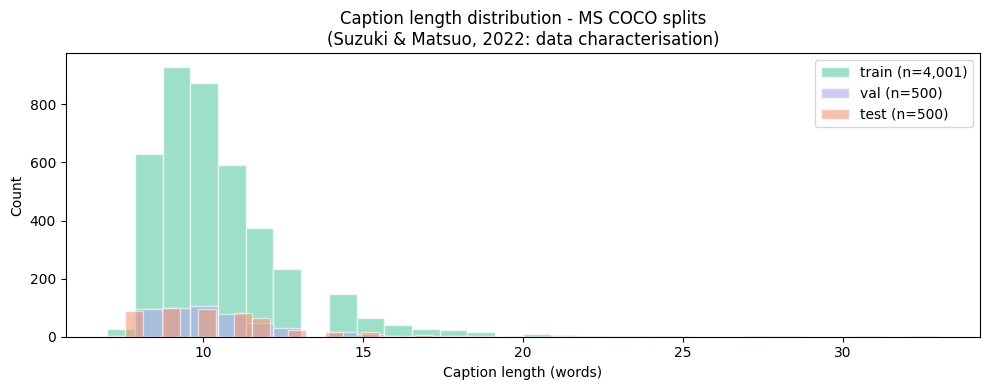


Saved: /content/drive/MyDrive/dissertation_final/results/week2_caption_lengths.png


In [ ]:
# CELL 6 - Caption length distribution

print('[Step 1/4] Caption length analysis...')

all_lengths = {'train': [], 'val': [], 'test': []}
for split, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    for caps_str in df['captions']:
        for cap in caps_str.split(' | '):
            all_lengths[split].append(len(cap.split()))

fig, ax = plt.subplots(figsize=(10, 4))
colors  = {'train': '#5DCAA5', 'val': '#AFA9EC', 'test': '#F0997B'}

for split, lengths in all_lengths.items():
    ax.hist(lengths, bins=30, alpha=0.6,
            label=f'{split} (n={len(lengths):,})',
            color=colors[split], edgecolor='white')
    print(f'  {split:5s} - mean: {np.mean(lengths):.1f} words | '
          f'std: {np.std(lengths):.1f} | '
          f'min: {min(lengths)} | max: {max(lengths)}')

ax.set_xlabel('Caption length (words)')
ax.set_ylabel('Count')
ax.set_title('Caption length distribution - MS COCO splits\n(Suzuki & Matsuo, 2022: data characterisation)')
ax.legend()
plt.tight_layout()

out = f'{RESULTS_DIR}/week2_caption_lengths.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out}')

## Step 2 - COCO category distribution

Shows which object categories appear most in your 1k sampled images.
Directly informs the COCO-grounded direction vectors used in Week 5.


[Step 2/4] Category distribution...


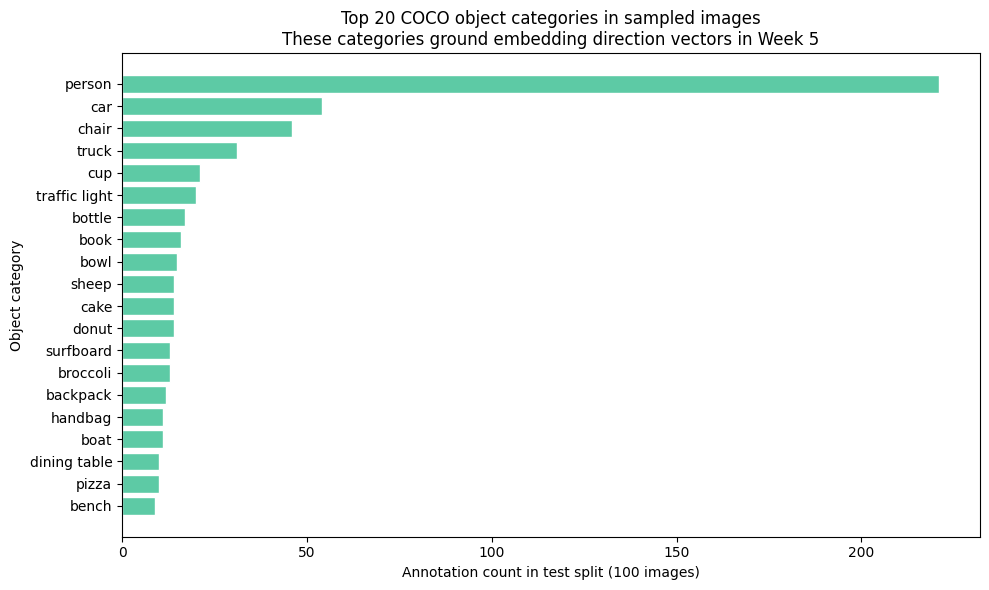

  Top 5 categories: ['person', 'car', 'chair', 'truck', 'cup']
  Saved: /content/drive/MyDrive/dissertation_final/results/week2_category_distribution.png


In [ ]:
# CELL 7 - COCO category distribution

print('[Step 2/4] Category distribution...')

if not os.path.exists(COCO_INST_FILE):
    print(f'  instances_val2017.json not found at {COCO_INST_FILE}')
    print('  Skipping category analysis.')
    print('  This file is in the annotations zip downloaded in week1_data.')
else:
    with open(COCO_INST_FILE) as f:
        inst = json.load(f)

    cat_map     = {c['id']: c['name'] for c in inst['categories']}
    sampled_ids = set(test_df['image_id'].tolist())
    cat_counts  = Counter()

    for ann in inst['annotations']:
        if ann['image_id'] in sampled_ids:
            cat_counts[cat_map[ann['category_id']]] += 1

    top20        = cat_counts.most_common(20)
    cats, counts = zip(*top20)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(list(reversed(cats)), list(reversed(counts)),
            color='#5DCAA5', edgecolor='white')
    ax.set_xlabel('Annotation count in test split (100 images)')
    ax.set_ylabel('Object category')
    ax.set_title(
        'Top 20 COCO object categories in sampled images\n'
        'These categories ground embedding direction vectors in Week 5'
    )
    plt.tight_layout()

    out = f'{RESULTS_DIR}/week2_category_distribution.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'  Top 5 categories: {list(cats[:5])}')
    print(f'  Saved: {out}')

## Step 3 - End-to-end sanity check

Runs the complete pipeline (image -> LLaVA -> caption -> BLEU + CLIP) on 10 images.

**If BLEU-4 > 0 and CLIP score > 0.15 -> pipeline verified.**

In [ ]:
# CELL 8 - Load LLaVA

def load_llava(cache_dir=MODEL_CACHE):
    load_from = cache_dir if os.path.exists(f'{cache_dir}/config.json') \
                else 'llava-hf/llava-v1.6-mistral-7b-hf'

    if load_from == MODEL_CACHE:
        print(f'Loading from Drive cache: {load_from}')
    else:
        print(f'Downloading from HuggingFace (first run ~14GB)...')

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        free = torch.cuda.mem_get_info()[0] / 1e9
        print(f'Free VRAM: {free:.1f} GB')

    processor = LlavaProcessor.from_pretrained(load_from, use_fast=False)
    model     = LlavaNextForConditionalGeneration.from_pretrained(
        load_from,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    model.eval()

    used = (
        torch.cuda.get_device_properties(0).total_memory
        - torch.cuda.mem_get_info()[0]
    ) / 1e9 if torch.cuda.is_available() else 0

    print(f'Model on    : {next(model.parameters()).device}')
    print(f'Model dtype : {next(model.parameters()).dtype}')
    print(f'VRAM used   : {used:.1f} GB')
    return processor, model

processor, model = load_llava()
print('\nLLaVA ready for sanity check.')

Loading from Drive cache: /content/drive/MyDrive/dissertation_final/models/llava_cache
Free VRAM: 69.5 GB


Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

Model on    : cuda:0
Model dtype : torch.float16
VRAM used   : 24.7 GB

LLaVA ready for sanity check.


In [ ]:
# CELL 9 - generate_caption()

def generate_caption(processor, model, image,
                     prompt='Describe this image in detail.',
                     max_new_tokens=100):
    conversation = [{
        'role': 'user',
        'content': [{'type': 'image'}, {'type': 'text', 'text': prompt}],
    }]
    text_input = processor.apply_chat_template(
        conversation, add_generation_prompt=True
    )
    inputs = processor(
        images=image, text=text_input, return_tensors='pt'
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, temperature=None, top_p=None,
        )

    caption = processor.batch_decode(
        output_ids[:, inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )[0]
    return caption.strip()

print('generate_caption() ready.')

generate_caption() ready.


In [ ]:
# CELL 10 - BLEU + CLIP score functions

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import CLIPProcessor, CLIPModel

_clip_proc, _clip_model = None, None

def load_clip():
    global _clip_proc, _clip_model
    if _clip_model is None:
        print('Loading CLIP (Radford et al., 2021)...')
        _clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
        _clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
        dev         = 'cuda' if torch.cuda.is_available() else 'cpu'
        _clip_model = _clip_model.to(dev).eval()
        print('CLIP ready.')
    return _clip_proc, _clip_model

def compute_sentence_bleu(gen, refs):
    s = SmoothingFunction().method1
    return round(
        sentence_bleu([r.lower().split() for r in refs],
                      gen.lower().split(), smoothing_function=s), 4
    )

def compute_clip_score(image, caption):
    proc, mdl = load_clip()
    dev       = next(mdl.parameters()).device
    inputs    = proc(text=[caption], images=image,
                     return_tensors='pt', padding=True,
                     truncation=True, max_length=77)
    inputs    = {k: v.to(dev) for k, v in inputs.items()}
    with torch.no_grad():
        out   = mdl(**inputs)
        i_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        t_emb = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
    return round((i_emb * t_emb).sum(dim=-1).item(), 4)

print('BLEU + CLIP score functions ready.')

BLEU + CLIP score functions ready.


In [ ]:
# CELL 11 - Run sanity check on 10 images

print('[Step 3/4] End-to-end sanity check (n=10)...')
print('='*55)

records = []
sample  = test_df.head(SANITY_N)

for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Sanity check'):
    image = Image.open(row['img_path']).convert('RGB')
    gen   = generate_caption(processor, model, image,
                              prompt='Describe this image in detail.')
    refs  = row['captions'].split(' | ')
    bleu4 = compute_sentence_bleu(gen, refs)
    clip  = compute_clip_score(image, gen)

    print(f'\n  [{row["image_id"]}]')
    print(f'  Generated : {gen}')
    print(f'  Reference : {refs[0]}')
    print(f'  BLEU-4={bleu4:.3f}  CLIP={clip:.3f}')

    records.append({
        'image_id':  row['image_id'],
        'img_path':  row['img_path'],
        'generated': gen,
        'reference': refs[0],
        'bleu4':     bleu4,
        'clip_score': clip,
    })

sanity_df = pd.DataFrame(records)

print('\n' + '='*55)
print(f'Sanity check aggregate (n={SANITY_N}):')
print(f'  Mean BLEU-4    : {sanity_df["bleu4"].mean():.4f}')
print(f'  Mean CLIP score: {sanity_df["clip_score"].mean():.4f}')
print()
if sanity_df['bleu4'].mean() > 0 and sanity_df['clip_score'].mean() > 0.15:
    print('STATUS: PIPELINE VERIFIED')
    print('Both metrics > 0 -- LLaVA is working correctly on COCO.')
else:
    print('WARNING: Low scores detected -- check model loading.')
    print('Re-run Cell 8 (load_llava) and retry.')

[Step 3/4] End-to-end sanity check (n=10)...


Sanity check:   0%|          | 0/10 [00:00<?, ?it/s]

Loading CLIP (Radford et al., 2021)...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

...


  [507893]
  Generated : The image captures a serene and well-organized bathroom. Dominating the scene is a pristine white bathtub, its surface gleaming under the soft light. Adjacent to the bathtub, a white toilet stands, its lid closed. Above the bathtub, a window with a white frame allows a glimpse of the world outside. The window is adorned with white blinds, partially drawn to let in a soft light that illuminates the room
  Reference : The bathroom is white and looks very clean.
  BLEU-4=0.009  CLIP=0.330


Sanity check:  90%|█████████ | 9/10 [01:07<00:04,  4.88s/it]


  [429109]
  Generated : The image captures a vibrant scene at a bus station. Dominating the foreground is a white bus, adorned with a purple stripe and the words "LNEA EXPRESS" in bold red letters. This bus is in motion, driving away from the camera.

In the background, a red bus is stationary, parked at the bus stop. It's a striking contrast to the white bus in the foreground. The bus stop itself is a bustling hub
  Reference : A street filled with buses and a white van.
  BLEU-4=0.010  CLIP=0.320


Sanity check: 100%|██████████| 10/10 [01:12<00:00,  7.20s/it]


  [315492]
  Generated : In the heart of a cozy bathroom, a young child is engrossed in a playful activity. The child, dressed in a vibrant red and black striped shirt, is kneeling on the floor, their attention captivated by a white plate. The plate, held securely in the child's hands, is adorned with a single brown teddy bear. The child's blonde hair is neatly tied back, allowing for a clear view of their
  Reference : A girl is playing with a teddy bear in a bathroom.
  BLEU-4=0.011  CLIP=0.364

Sanity check aggregate (n=10):
  Mean BLEU-4    : 0.0208
  Mean CLIP score: 0.3070

STATUS: PIPELINE VERIFIED
Both metrics > 0 -- LLaVA is working correctly on COCO.


In [ ]:
# CELL 12 - Save sanity check results

out = f'{RESULTS_DIR}/week2_sanity_check.csv'
sanity_df.to_csv(out, index=False)
print(f'Saved: {out}')
print(sanity_df[['image_id','generated','reference','bleu4','clip_score']].to_string(index=False))

Saved: /content/drive/MyDrive/dissertation_final/results/week2_sanity_check.csv
 image_id                                                                                                                                                                                                                                                                                                                                                                                                                                 generated                                                      reference  bleu4  clip_score
   577864                  In the heart of a gravel field, a lively game of soccer unfolds. Two players, clad in vibrant red and black jerseys, are caught in the midst of action. The player in the red jersey, positioned on the left side of the image, is in the process of kicking the ball, sending it flying towards the right side of the image. \n\nOn the right side of the image, the player in the bla

## Step 4 - Inference preview grid

Shows generated captions vs reference captions for 9 images.

[Step 4/4] Building inference preview grid...


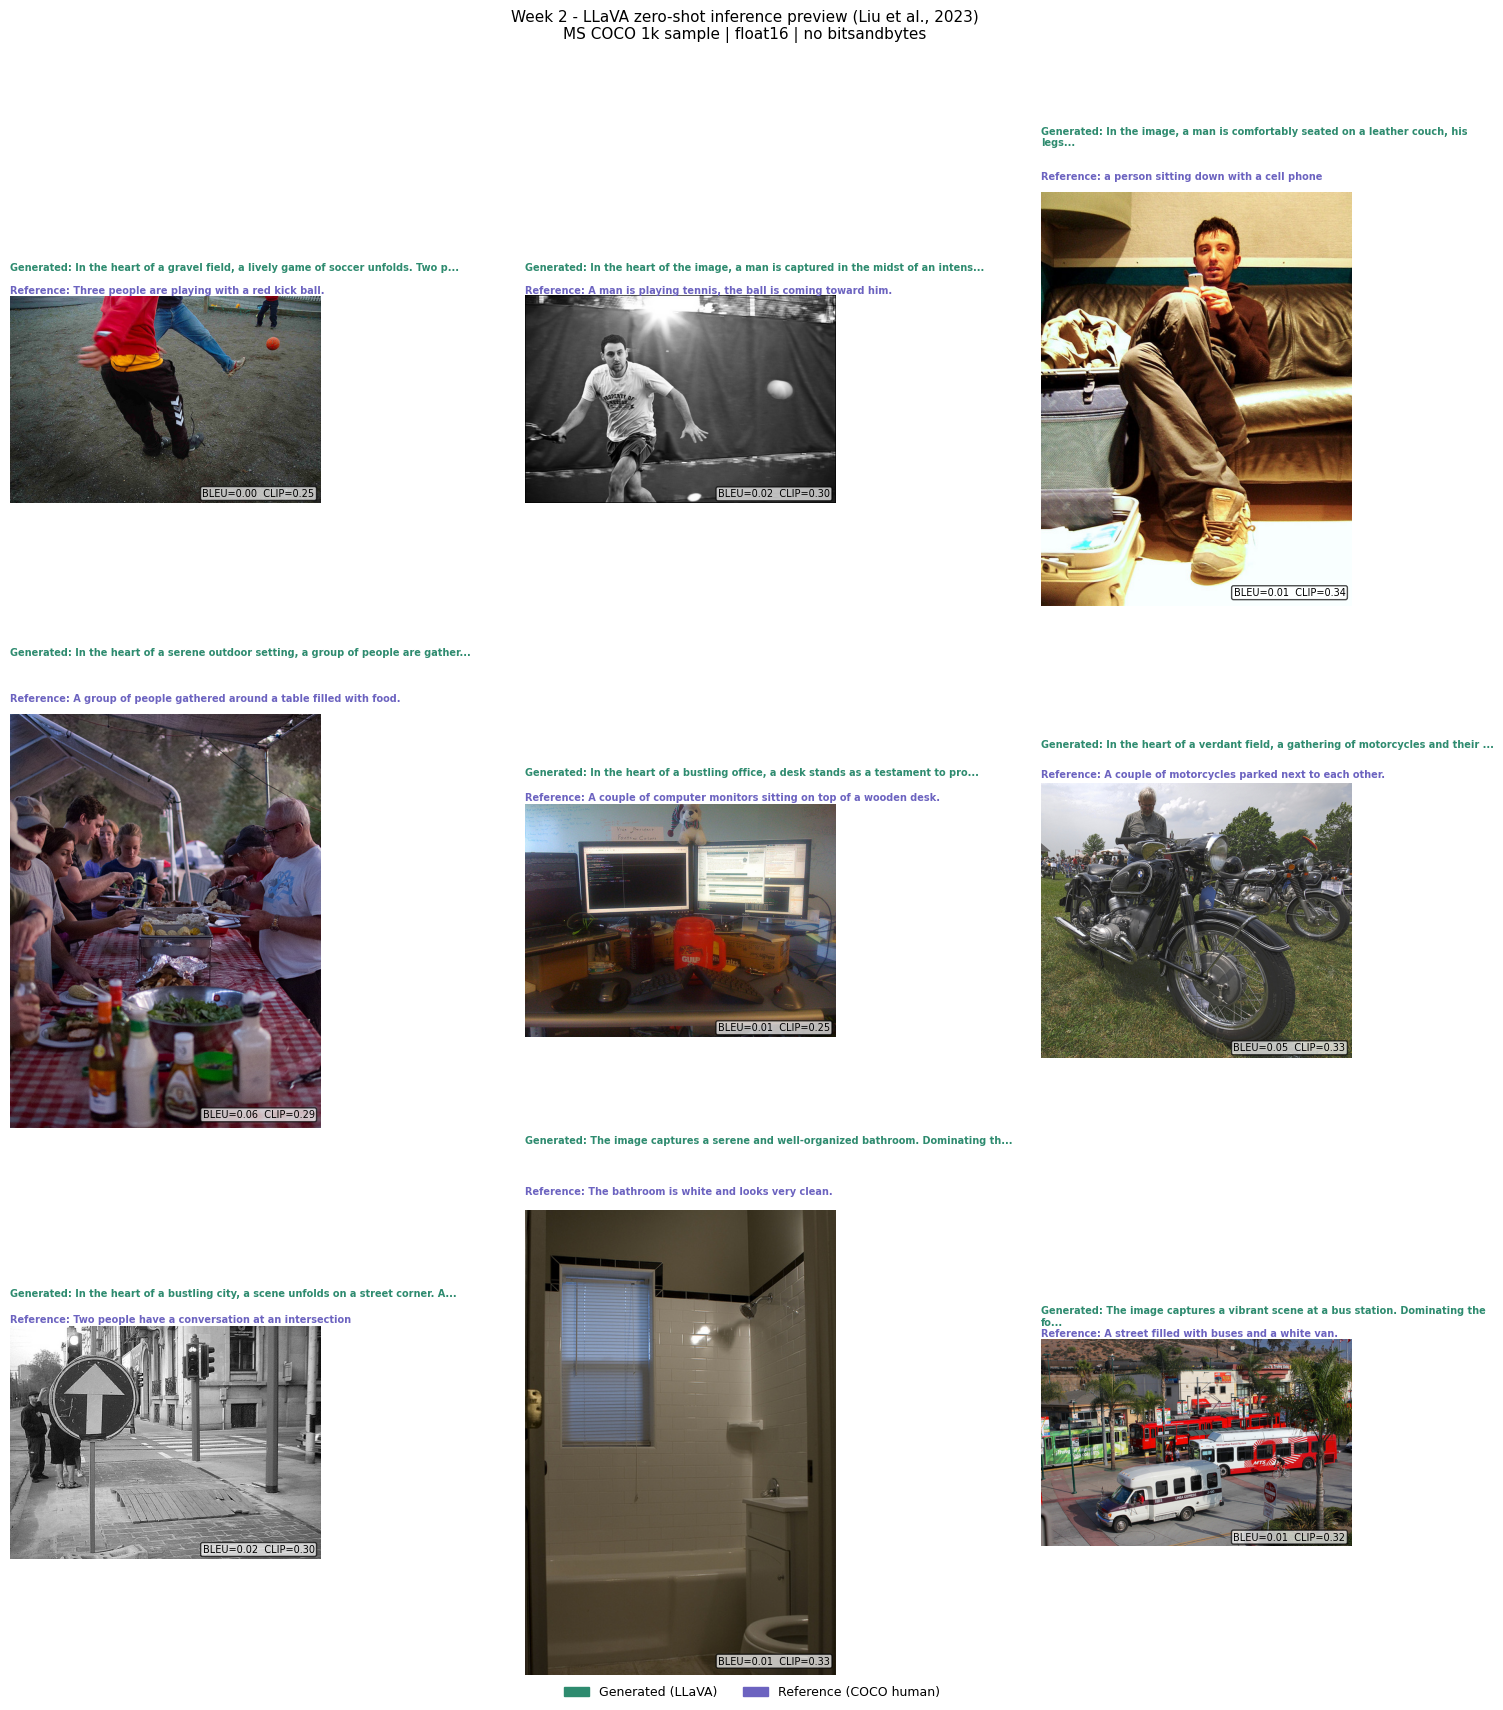

Saved: /content/drive/MyDrive/dissertation_final/results/week2_inference_preview.png


In [ ]:
# CELL 13 - Inference preview grid

print('[Step 4/4] Building inference preview grid...')

n    = min(9, len(sanity_df))
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5.6))
axes      = axes.flatten()

for i, (_, row) in enumerate(sanity_df.head(n).iterrows()):
    img = Image.open(row['img_path']).convert('RGB')
    axes[i].imshow(img)
    axes[i].axis('off')

    gen = row['generated'][:70] + '...' if len(row['generated']) > 70 else row['generated']
    ref = row['reference'][:70]  + '...' if len(row['reference'])  > 70 else row['reference']


    axes[i].text(
        0.0, 1.16, f'Generated: {gen}',
        transform=axes[i].transAxes,
        fontsize=7, color='#2E8B6F', fontweight='bold',
        ha='left', va='top', wrap=True,
    )
    axes[i].text(
        0.0, 1.05, f'Reference: {ref}',
        transform=axes[i].transAxes,
        fontsize=7, color='#6C63C0', fontweight='bold',
        ha='left', va='top', wrap=True,
    )

    axes[i].text(
        0.98, 0.02,
        f'BLEU={row["bleu4"]:.2f}  CLIP={row["clip_score"]:.2f}',
        transform=axes[i].transAxes,
        fontsize=7, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
    )

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

gen_patch = mpatches.Patch(color='#2E8B6F', label='Generated (LLaVA)')
ref_patch = mpatches.Patch(color='#6C63C0', label='Reference (COCO human)')
fig.legend(handles=[gen_patch, ref_patch],
           loc='lower center', ncol=2, fontsize=9, frameon=False)

plt.suptitle(
    'Week 2 - LLaVA zero-shot inference preview (Liu et al., 2023)\n'
    'MS COCO 1k sample | float16 | no bitsandbytes',
    fontsize=11, y=1.01
)
plt.tight_layout()

out = f'{RESULTS_DIR}/week2_inference_preview.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [ ]:
# CELL 14 - Dataset statistics summary

print('Dataset statistics for dissertation methodology chapter:')
print('='*55)

for split, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    all_caps = []
    for caps_str in df['captions']:
        all_caps.extend(caps_str.split(' | '))
    lengths = [len(c.split()) for c in all_caps]
    print(f'{split:6s}: {len(df):>3} images | '
          f'{len(all_caps):>4} captions | '
          f'mean length: {np.mean(lengths):.1f} words | '
          f'std: {np.std(lengths):.1f}')

print()
print('Sanity check summary:')
print(f'  Mean BLEU-4    : {sanity_df["bleu4"].mean():.4f}')
print(f'  Mean CLIP score: {sanity_df["clip_score"].mean():.4f}')
print(f'  Min CLIP score : {sanity_df["clip_score"].min():.4f}')
print(f'  Max CLIP score : {sanity_df["clip_score"].max():.4f}')
print()
print('Write in methodology chapter:')
print(f'  "The MS COCO 2017 validation split was sampled to produce')
print(f'  1,000 image-caption pairs split 80/10/10 for training, validation,')
print(f'  and testing respectively. Each image has a mean of 5 reference')
print(f'  captions with average length {np.mean([len(c.split()) for df in [train_df,val_df,test_df] for caps in df["captions"] for c in caps.split(" | ")]):.1f} words."')

Dataset statistics for dissertation methodology chapter:
Train : 800 images | 4001 captions | mean length: 10.4 words | std: 2.3
Val   : 100 images |  500 captions | mean length: 10.5 words | std: 2.7
Test  : 100 images |  500 captions | mean length: 10.5 words | std: 2.2

Sanity check summary:
  Mean BLEU-4    : 0.0208
  Mean CLIP score: 0.3070
  Min CLIP score : 0.2466
  Max CLIP score : 0.3641

Write in methodology chapter:
  "The MS COCO 2017 validation split was sampled to produce
  1,000 image-caption pairs split 80/10/10 for training, validation,
  and testing respectively. Each image has a mean of 5 reference
  captions with average length 10.4 words."


In [ ]:
# CELL 15 - Final verification

print('='*55)
print('Week 2 - Final verification')
print('='*55)

files_to_check = [
    f'{PROCESSED_DIR}/train.csv',
    f'{PROCESSED_DIR}/val.csv',
    f'{PROCESSED_DIR}/test.csv',
    f'{RESULTS_DIR}/week1_first_inference.csv',
    f'{RESULTS_DIR}/week2_caption_lengths.png',
    f'{RESULTS_DIR}/week2_sanity_check.csv',
    f'{RESULTS_DIR}/week2_inference_preview.png',
]

if os.path.exists(COCO_INST_FILE):
    files_to_check.append(f'{RESULTS_DIR}/week2_category_distribution.png')

all_ok = True
for fpath in files_to_check:
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) if exists else 0
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}] {os.path.basename(fpath):40s} {size:>10,} bytes')
    if not exists:
        all_ok = False

print()
if all_ok:
    print('Week 2 complete.')
    print()
    print('Pipeline verified:')
    print(f'  BLEU-4     = {sanity_df["bleu4"].mean():.4f}  (> 0 = OK)')
    print(f'  CLIP score = {sanity_df["clip_score"].mean():.4f}  (> 0.15 = OK)')
    print()
    print('Next: open week3_baseline_colab.ipynb')
else:
    print('Some files missing. Re-run the cells above.')

Week 2 - Final verification
  [OK] train.csv                                   302,367 bytes
  [OK] val.csv                                      37,928 bytes
  [OK] test.csv                                     38,190 bytes
  [OK] week1_first_inference.csv                     8,404 bytes
  [OK] week2_caption_lengths.png                    50,616 bytes
  [OK] week2_sanity_check.csv                        5,625 bytes
  [OK] week2_inference_preview.png               3,647,283 bytes
  [OK] week2_category_distribution.png              76,958 bytes

Week 2 complete.

Pipeline verified:
  BLEU-4     = 0.0208  (> 0 = OK)
  CLIP score = 0.3070  (> 0.15 = OK)

Next: open week3_baseline_colab.ipynb
